In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)

# Modelos de árvore
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Rede neural
from sklearn.neural_network import MLPClassifier

# Interpretabilidade
import shap
from sklearn.inspection import permutation_importance

# Salvamento
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

SEED = 42
np.random.seed(SEED)
print("Ambiente configurado.")

Ambiente configurado.


In [2]:
df = pd.read_parquet("data/gold/gold_escolas_evasao.parquet")
print(f"Dimensões originais: {df.shape}")

# Features a serem removidas (usadas na criação do target)
cols_regra = ['QT_TUR_EJA', 'prop_turmas_eja', 'QT_DOC_BAS', 'QT_TUR_BAS', 'docentes_por_turma']
df_clean = df.drop(columns=[c for c in cols_regra if c in df.columns], errors='ignore')
print(f"Dimensões após remoção: {df_clean.shape}")

# Verificar distribuição do target
print("\nDistribuição do target:")
print(df_clean['target_evasao'].value_counts(normalize=True))

df_clean.head()

Dimensões originais: (178772, 16)
Dimensões após remoção: (178772, 11)

Distribuição do target:
target_evasao
0    0.727782
1    0.272218
Name: proportion, dtype: float64


,CO_ENTIDADE,CO_MUNICIPIO,CO_UF,QT_DOC_BAS_FEM,QT_DOC_BAS_MASC,QT_GESTORES,QT_TUR_MED,QT_TUR_PROF,tem_ensino_medio,tem_profissional,target_evasao
0,11022558,1100015,11,0.0,1.0,1.0,0.0,0.0,0,0,1
1,11024275,1100015,11,5.0,4.0,1.0,0.0,0.0,0,0,1
2,11024666,1100015,11,10.0,3.0,1.0,0.0,0.0,0,0,0
3,11024682,1100015,11,24.0,20.0,1.0,28.0,5.0,1,1,0
4,11024917,1100015,11,8.0,3.0,1.0,0.0,0.0,0,0,0


In [3]:
# Identificar se há múltiplas linhas por escola
if 'CO_ENTIDADE' in df_clean.columns:
    n_entidades = df_clean['CO_ENTIDADE'].nunique()
    print(f"Total de registros: {len(df_clean)} | Escolas únicas: {n_entidades}")
    use_group_split = (n_entidades < len(df_clean))
else:
    use_group_split = False

# Definir features (X) e target (y)
features = [c for c in df_clean.columns if c not in ['CO_ENTIDADE', 'CO_MUNICIPIO', 'target_evasao']]
X = df_clean[features]
y = df_clean['target_evasao']
groups = df_clean['CO_ENTIDADE'] if use_group_split else None

if use_group_split:
    from sklearn.model_selection import GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]
    groups_test  = groups.iloc[test_idx]
    print("Divisão por grupo (escola) aplicada.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    groups_train = groups_test = None
    print("Divisão aleatória estratificada aplicada.")

print(f"\nTreino: {X_train.shape[0]} amostras | Proporção evasão: {y_train.mean():.2%}")
print(f"Teste:  {X_test.shape[0]} amostras | Proporção evasão: {y_test.mean():.2%}")


Total de registros: 178772 | Escolas únicas: 178772
Divisão aleatória estratificada aplicada.

Treino: 143017 amostras | Proporção evasão: 27.22%
Teste:  35755 amostras | Proporção evasão: 27.22%


In [4]:
# Pipeline de imputação
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])

preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_features)])
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# DataFrames para facilitar manipulação (opcional)
X_train_proc = pd.DataFrame(X_train_proc, columns=numeric_features, index=X_train.index)
X_test_proc  = pd.DataFrame(X_test_proc, columns=numeric_features, index=X_test.index)

# Normalização para rede neural (scaler separado)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_proc)
X_test_scaled  = scaler.transform(X_test_proc)

print("Pré-processamento concluído.")

Pré-processamento concluído.


In [5]:
from sklearn.model_selection import StratifiedGroupKFold

def evaluate_model(model, X, y, groups=None, cv=5):
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    if groups is not None:
        cv_strategy = StratifiedGroupKFold(n_splits=cv, shuffle=True, random_state=SEED)
    else:
        cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    
    scores = cross_validate(model, X, y, groups=groups, cv=cv_strategy, scoring=scoring, n_jobs=-1)
    
    results = {}
    for metric in scoring:
        results[metric] = {'mean': scores[f'test_{metric}'].mean(), 'std': scores[f'test_{metric}'].std()}
    return results

# Definir modelos com regularização
models_tree = {
    'Decision Tree': DecisionTreeClassifier(random_state=SEED, max_depth=4, min_samples_leaf=50),
    'Random Forest': RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=8,
                                            min_samples_leaf=20, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=SEED, n_estimators=100, max_depth=5, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                             eval_metric='logloss', scale_pos_weight=(y_train.value_counts()[0]/y_train.value_counts()[1])),
    'LightGBM': LGBMClassifier(random_state=SEED, n_estimators=100, max_depth=5, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                               class_weight='balanced', verbose=-1)
}

results_tree = {}
for name, model in models_tree.items():
    print(f"Avaliando {name}...")
    results_tree[name] = evaluate_model(model, X_train_proc, y_train, groups=groups_train)
    print(f"  AUC-ROC: {results_tree[name]['roc_auc']['mean']:.4f} ± {results_tree[name]['roc_auc']['std']:.4f}")

# Tabela comparativa
df_results_tree = pd.DataFrame({
    name: {m: f"{res[m]['mean']:.4f} ± {res[m]['std']:.4f}" for m in ['accuracy','precision','recall','f1','roc_auc']}
    for name, res in results_tree.items()
}).T
df_results_tree


Avaliando Decision Tree...
  AUC-ROC: 0.6719 ± 0.0039
Avaliando Random Forest...
  AUC-ROC: 0.7206 ± 0.0034
Avaliando XGBoost...
  AUC-ROC: 0.7257 ± 0.0034
Avaliando LightGBM...
  AUC-ROC: 0.7248 ± 0.0035


,accuracy,precision,recall,f1,roc_auc
Decision Tree,0.7306 ± 0.0010,0.7538 ± 0.1035,0.0182 ± 0.0070,0.0354 ± 0.0130,0.6719 ± 0.0039
Random Forest,0.6014 ± 0.0020,0.3849 ± 0.0017,0.7757 ± 0.0059,0.5145 ± 0.0025,0.7206 ± 0.0034
XGBoost,0.6326 ± 0.0027,0.4033 ± 0.0024,0.7287 ± 0.0088,0.5192 ± 0.0034,0.7257 ± 0.0034
LightGBM,0.6310 ± 0.0031,0.4019 ± 0.0028,0.7287 ± 0.0087,0.5181 ± 0.0039,0.7248 ± 0.0035


In [8]:
from sklearn.utils.class_weight import compute_sample_weight 
# Criação do MLP (sem pesos para CV)
mlp_cv = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=256,
    learning_rate='adaptive',
    max_iter=50,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)

print("Avaliando MLP com validação cruzada (sem balanceamento)...")
results_mlp = evaluate_model(mlp_cv, X_train_scaled, y_train, groups=groups_train)
print(f"MLP - AUC-ROC: {results_mlp['roc_auc']['mean']:.4f} ± {results_mlp['roc_auc']['std']:.4f}")

# Modelo final com pesos balanceados
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=256,
    learning_rate='adaptive',
    max_iter=100,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=True
)

sample_weights = compute_sample_weight('balanced', y=y_train)
mlp.fit(X_train_scaled, y_train, sample_weight=sample_weights)

Avaliando MLP com validação cruzada (sem balanceamento)...
MLP - AUC-ROC: 0.7290 ± 0.0042
Iteration 1, loss = 0.64038216
Validation score: 0.637456
Iteration 2, loss = 0.62774477
Validation score: 0.646507
Iteration 3, loss = 0.62102144
Validation score: 0.654471
Iteration 4, loss = 0.61698563
Validation score: 0.656268
Iteration 5, loss = 0.61475674
Validation score: 0.657856
Iteration 6, loss = 0.61253263
Validation score: 0.657721
Iteration 7, loss = 0.61134862
Validation score: 0.661069
Iteration 8, loss = 0.60943467
Validation score: 0.659890
Iteration 9, loss = 0.60871888
Validation score: 0.657882
Iteration 10, loss = 0.60771187
Validation score: 0.662809
Iteration 11, loss = 0.60709154
Validation score: 0.659131
Iteration 12, loss = 0.60638680
Validation score: 0.665340
Iteration 13, loss = 0.60537729
Validation score: 0.663618
Iteration 14, loss = 0.60481658
Validation score: 0.662926
Iteration 15, loss = 0.60440522
Validation score: 0.665436
Iteration 16, loss = 0.60382709
Va

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.001
,batch_size,256
,learning_rate,'adaptive'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,100
,shuffle,True
,random_state,42


In [9]:
# Treinar os modelos de árvore no treino completo
for name, model in models_tree.items():
    model.fit(X_train_proc, y_train)

# Avaliar no teste
def evaluate_on_test(model, X_test, y_test, model_name, is_nn=False):
    if is_nn:
        X_test_used = scaler.transform(X_test)  # X_test_proc normalizado
    else:
        X_test_used = X_test
    y_pred = model.predict(X_test_used)
    y_proba = model.predict_proba(X_test_used)[:, 1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        'Modelo': model_name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }
    return metrics, y_pred, y_proba

test_results = []
predictions = {}
predictions_adjusted = {}  # Para armazenar as predições ajustadas

# Avaliar modelos de árvore
for name, model in models_tree.items():
    met, yp, yprob = evaluate_on_test(model, X_test_proc, y_test, name)
    test_results.append(met)
    predictions[name] = (yp, yprob)

# Avaliar MLP e encontrar melhor limiar para a rede neural
met_mlp, yp_mlp, yprob_mlp = evaluate_on_test(mlp, X_test_proc, y_test, 'MLP (Rede Neural)', is_nn=True)
test_results.append(met_mlp)
predictions['MLP'] = (yp_mlp, yprob_mlp)

# Ajuste de limiar para o MLP
from sklearn.metrics import f1_score
thresholds = np.linspace(0.1, 0.9, 50)
best_t = 0.5
best_f1 = 0
for t in thresholds:
    y_pred_t = (yprob_mlp >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"Limiar ajustado para MLP (max F1): {best_t:.2f}")

# Criar predições ajustadas
y_pred_mlp_adjusted = (yprob_mlp >= best_t).astype(int)
predictions_adjusted['MLP'] = (y_pred_mlp_adjusted, yprob_mlp)

# Atualizar as métricas do MLP no DataFrame com as métricas ajustadas
met_mlp_adjusted = {
    'Acurácia': accuracy_score(y_test, y_pred_mlp_adjusted),
    'Precisão': precision_score(y_test, y_pred_mlp_adjusted),
    'Recall': recall_score(y_test, y_pred_mlp_adjusted),
    'F1': f1_score(y_test, y_pred_mlp_adjusted),
    'AUC-ROC': met_mlp['AUC-ROC']  # AUC não muda com limiar
}

# Substituir as métricas do MLP pelas ajustadas
for i, result in enumerate(test_results):
    if result['Modelo'] == 'MLP (Rede Neural)':
        test_results[i].update(met_mlp_adjusted)
        break

# DataFrame final
df_test = pd.DataFrame(test_results).set_index('Modelo')
df_test

df_test = pd.DataFrame(test_results).set_index('Modelo')
df_test


Limiar ajustado para MLP (max F1): 0.49


,Acurácia,Precisão,Recall,F1,AUC-ROC
Modelo,,,,,
Decision Tree,0.730695,0.754902,0.015822,0.030995,0.668885
Random Forest,0.595609,0.380463,0.772732,0.509881,0.719067
XGBoost,0.629646,0.400431,0.724956,0.515903,0.721421
LightGBM,0.628276,0.399842,0.729683,0.516603,0.721328
MLP (Rede Neural),0.627744,0.400423,0.738929,0.519390,0.729805


In [11]:
# Melhor modelo baseado em AUC-ROC (se disponível)
best_model_name = df_test['AUC-ROC'].idxmax()
print(f"Melhor modelo no teste: {best_model_name} (AUC = {df_test.loc[best_model_name, 'AUC-ROC']:.4f})")

Melhor modelo no teste: MLP (Rede Neural) (AUC = 0.7298)


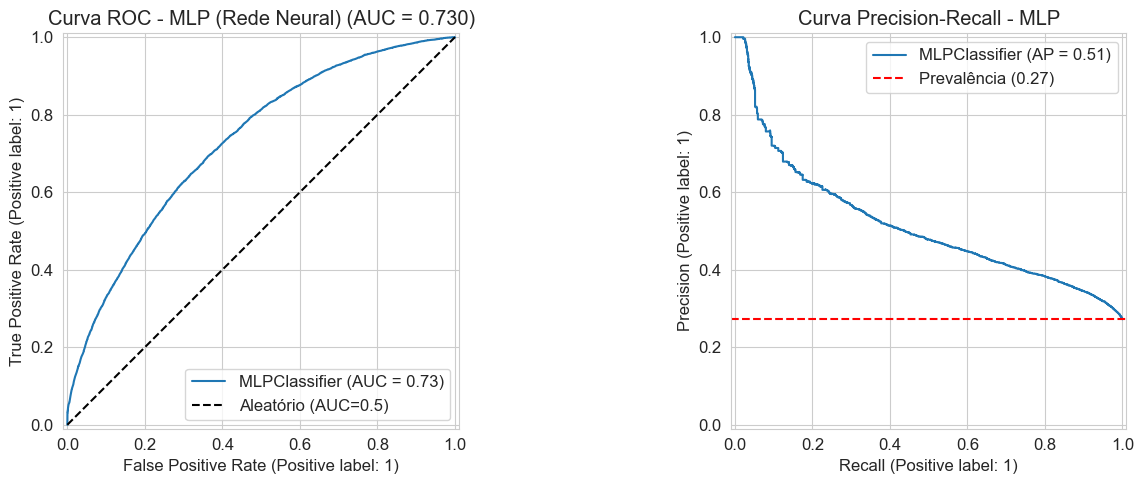

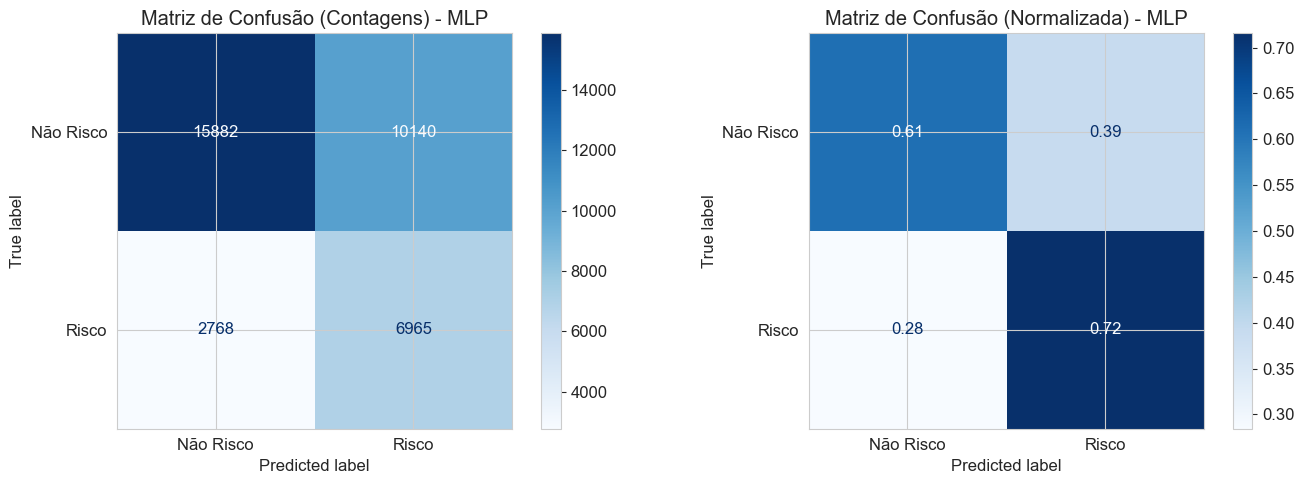

In [13]:
# Selecionar a Rede Neural MLP como melhor modelo
best_model = mlp
y_pred_best = predictions['MLP'][0]
y_proba_best = predictions['MLP'][1]
X_test_best = X_test_scaled  # MLP requer dados normalizados

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
RocCurveDisplay.from_estimator(best_model, X_test_best, y_test, ax=axes[0])
axes[0].plot([0,1], [0,1], 'k--', label='Aleatório (AUC=0.5)')
axes[0].set_title(f'Curva ROC - MLP (Rede Neural) (AUC = {df_test.loc["MLP (Rede Neural)", "AUC-ROC"]:.3f})')
axes[0].legend()

# Curva Precision-Recall
PrecisionRecallDisplay.from_estimator(best_model, X_test_best, y_test, ax=axes[1])
axes[1].set_title('Curva Precision-Recall - MLP')
axes[1].axhline(y=y_train.mean(), color='r', linestyle='--', label=f'Prevalência ({y_train.mean():.2f})')
axes[1].legend()
plt.tight_layout()
plt.show()

# Matriz de Confusão
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test_best, y_test, 
                                      display_labels=['Não Risco', 'Risco'],
                                      cmap='Blues', values_format='d', ax=ax[0])
ax[0].set_title('Matriz de Confusão (Contagens) - MLP')
ConfusionMatrixDisplay.from_estimator(best_model, X_test_best, y_test, 
                                      display_labels=['Não Risco', 'Risco'],
                                      cmap='Blues', normalize='true', values_format='.2f', ax=ax[1])
ax[1].set_title('Matriz de Confusão (Normalizada) - MLP')
plt.tight_layout()
plt.show()

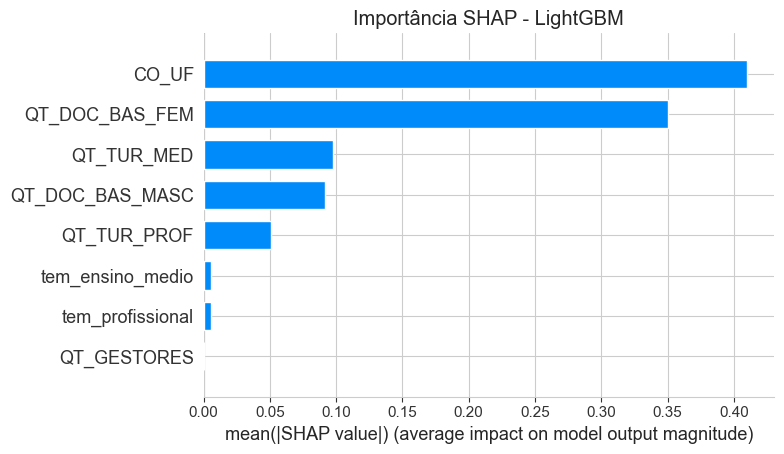

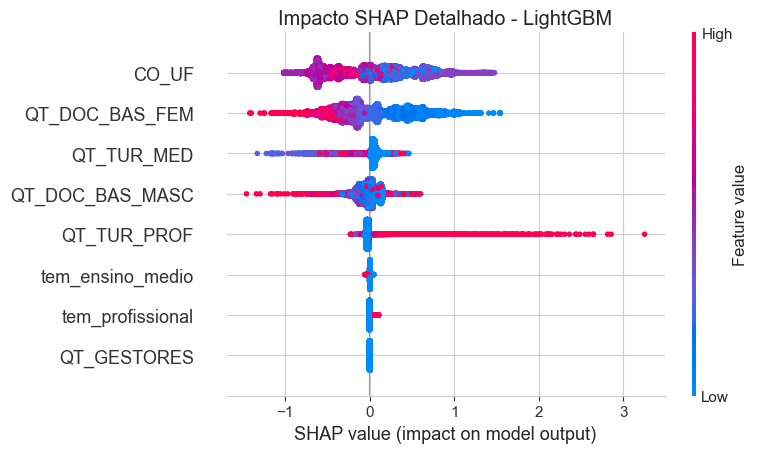

In [15]:
# Usar LightGBM para interpretabilidade SHAP
modelo_shap = models_tree['LightGBM']  # fixa o modelo de árvore

explainer = shap.TreeExplainer(modelo_shap)
shap_values = explainer.shap_values(X_test_proc)   # dados não escalonados
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

shap.summary_plot(shap_values_pos, X_test_proc, plot_type="bar", show=False)
plt.title('Importância SHAP - LightGBM')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_pos, X_test_proc, show=False)
plt.title('Impacto SHAP Detalhado - LightGBM')
plt.tight_layout()
plt.show()


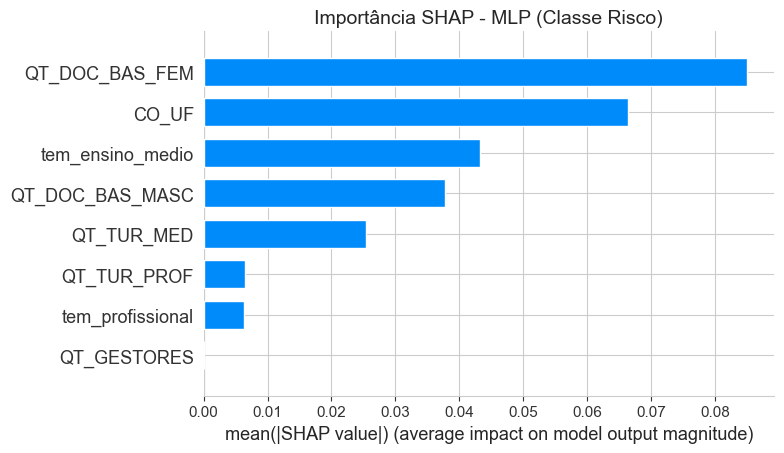

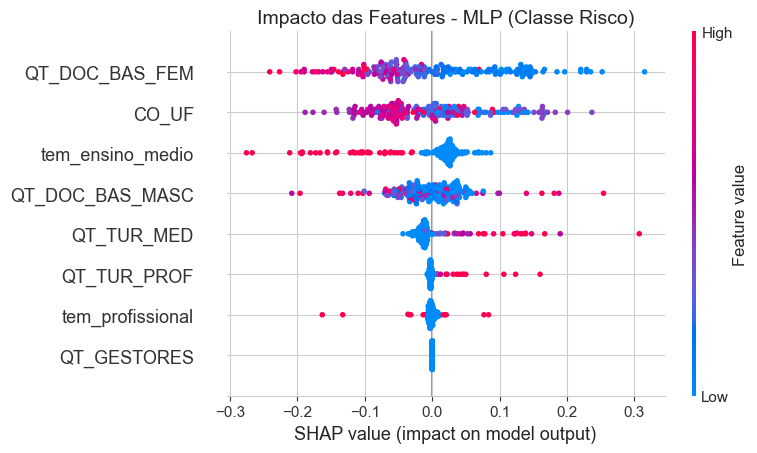

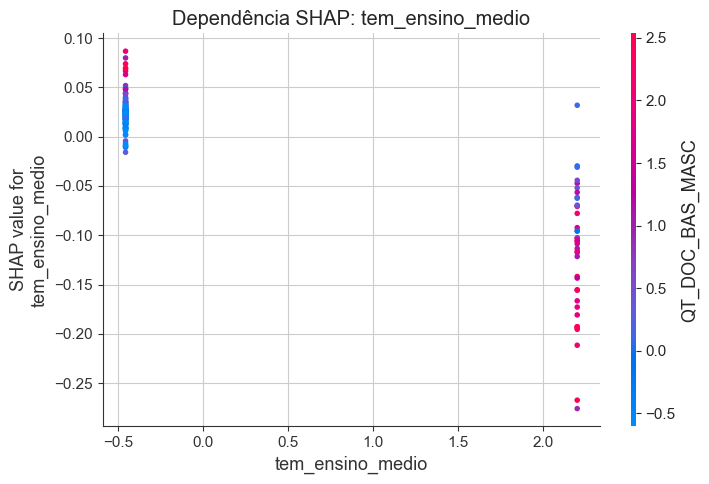

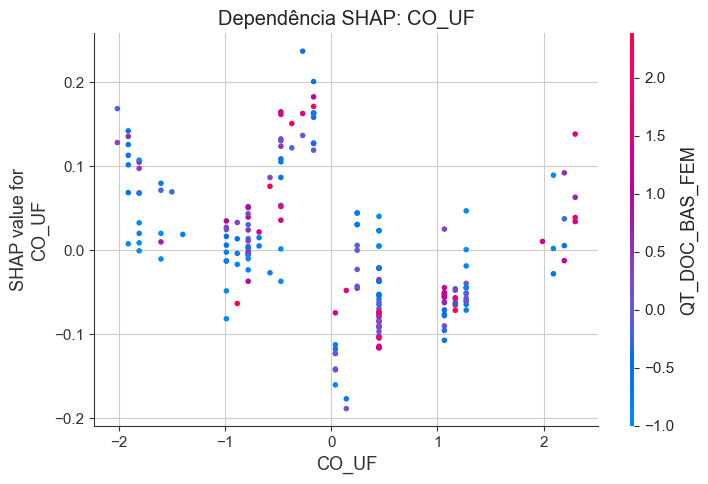

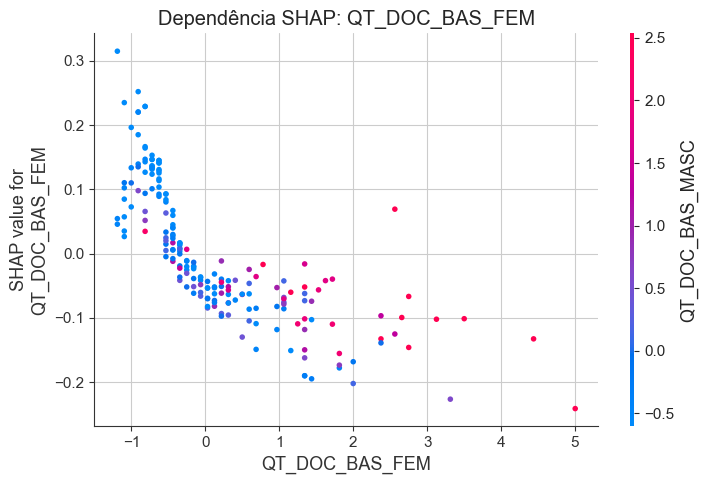

In [18]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Amostra para viabilizar o cálculo
X_sample = shap.utils.sample(X_test_scaled, 200)
explainer = shap.Explainer(best_model.predict_proba, X_sample)
shap_values = explainer(X_sample)

# Para classificação binária, pegar os valores SHAP da classe "Risco" (índice 1)
shap_risk = shap_values[:, :, 1]

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_risk, X_sample, plot_type="bar", feature_names=features, show=False)
plt.title("Importância SHAP - MLP (Classe Risco)", fontsize=14)
plt.tight_layout()
plt.show()

# Summary plot detalhado (beeswarm)
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_risk, X_sample, feature_names=features, show=False)
plt.title("Impacto das Features - MLP (Classe Risco)", fontsize=14)
plt.tight_layout()
plt.show()

# Gráficos de dependência para as top 3 features
top_features = np.argsort(np.abs(shap_risk.values).mean(0))[-3:]
for idx in top_features:
    shap.dependence_plot(idx, shap_risk.values, X_sample, feature_names=features, show=False)
    plt.title(f"Dependência SHAP: {features[idx]}")
    plt.tight_layout()
    plt.show()

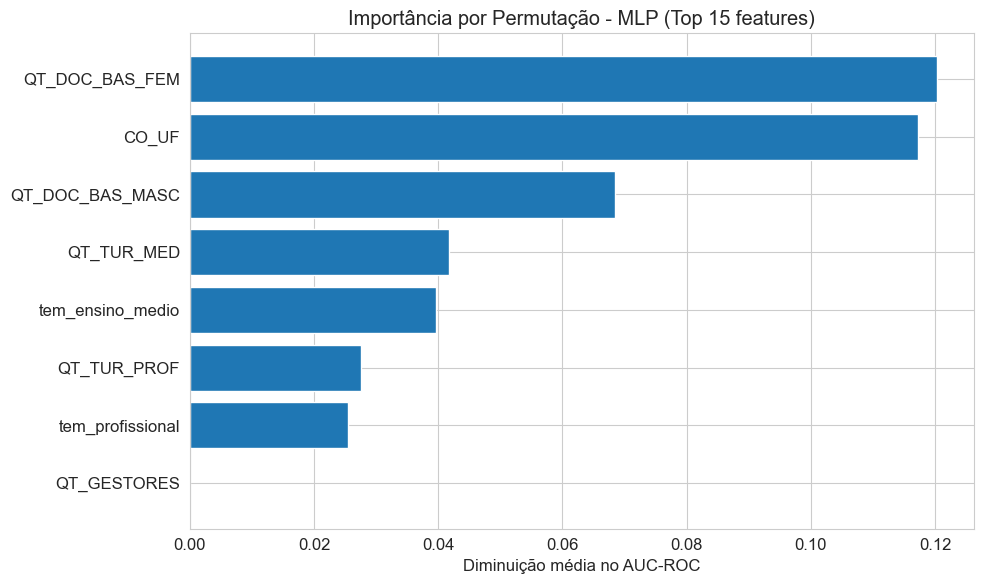

In [19]:
perm_importance = permutation_importance(mlp, X_test_scaled, y_test, n_repeats=10, random_state=SEED, scoring='roc_auc')
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.barh(np.array(features)[sorted_idx][:15], perm_importance.importances_mean[sorted_idx][:15])
plt.xlabel('Diminuição média no AUC-ROC')
plt.title('Importância por Permutação - MLP (Top 15 features)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()